In [38]:
# %% =========================================================
# cell 1. imports
# purpose:
# load the libraries needed for file handling, image loading,
# preprocessing, dataset construction, model building,
# training, evaluation, and passive learning
# ============================================================

import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import tifffile as tiff
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [39]:
# %% =========================================================
# cell. mount drive and inspect folders
# purpose:
# mount Google Drive and look at what folders/files actually exist
# before defining dataset paths
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

drive_root = Path("/content/drive/MyDrive")

print("drive root exists:", drive_root.exists())
print("\nfirst things in MyDrive:")
for p in list(drive_root.iterdir())[:30]:
    print(p.name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
drive root exists: True

first things in MyDrive:
BIOSAFETY TRAINING
Application materials
PROTOCOLS-LOGS
C1V1 and dilution practice problems.docx
ChemiDoc Images 2024-09-20_13.01.35
ChemiDoc Images 2024-09-20_12.57.30
Cx31.3_2.czi
Cx43_2.czi
Cx32_2.czi
Cx46_2.czi
Cx36_2.czi
Copy of Update 10  08 24-10 15 24 Yeritmary Rodriguez.gdoc
TFexcelsheet_template_AR.xlsx
Colocalization Script
3uM_37_10min_2_zstack.czi
Personal Statement YRD.gdoc
Saved from Chrome
SOP Coloc2 (Image J).gdoc
Images 1uM, 3uM and 5uM_RT_10 mins.gdoc
Presentation 11 25.gdoc
ABRCMS registartion evidence.gdoc
quick-guide-employee-time-off-corrections (1) (1).pdf
IMG_5766.heic
Lab website info.docx
crispr.gdoc
Colocalization Imaris.gdoc
Stories
lab pics.gdoc
Slice Load analysis SOP.gdoc
overlay z stack (JVP work).zip


In [55]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_dir = Path("/content/drive/MyDrive/ASR_Project")

active_history_path = project_dir / "active_history.csv"
passive_history_path = project_dir / "passive_history.csv"

print("active_history_path exists:", active_history_path.exists())
print("passive_history_path exists:", passive_history_path.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
active_history_path exists: True
passive_history_path exists: True


In [56]:
active_history_df = pd.read_csv(active_history_path)
passive_history_df = pd.read_csv(passive_history_path)

print("active history:")
print(active_history_df)

print("\npassive history:")
print(passive_history_df)

active history:
   round  labeled_size  unlabeled_size  num_selected_this_round  \
0      1            20             516                       10   
1      2            30             506                       10   
2      3            40             496                       10   

   mean_selected_uncertainty  test_loss  test_dice  test_iou  
0                   0.009596   0.862989   0.934686  0.879289  
1                   0.026837   0.717851   0.952117  0.910607  
2                   0.027387   0.696442   0.927272  0.867110  

passive history:
   round  labeled_size  unlabeled_size  num_selected_this_round  test_loss  \
0      1            20             516                       10   0.743217   
1      2            30             506                       10   0.675787   
2      3            40             496                       10   0.628407   

   test_dice  test_iou  
0   0.947757  0.903509  
1   0.897714  0.817047  
2   0.884519  0.795514  


In [40]:
# %% =========================================================
# cell. inspect ASR_Project folder
# purpose:
# see whether ASR_Project exists in Drive and what is inside it
# ============================================================

project_dir = Path("/content/drive/MyDrive/ASR_Project")

print("project_dir exists:", project_dir.exists())

if project_dir.exists():
    print("\ncontents of ASR_Project:")
    for p in project_dir.iterdir():
        print(p.name)
else:
    print("ASR_Project was not found in MyDrive.")

project_dir exists: True

contents of ASR_Project:
PassiveLearning.ipynb
DeepLearning.ipynb
PreprocessingData.ipynb
passive.ipynb
.DS_Store
ActiveLearning.ipynb
active_round_1_best_model.pt
DATA
active_model_final.pt
active_history.csv
passive_model_final.pt
passive_history.csv


In [41]:
# %% =========================================================
# cell. inspect DATA folder
# purpose:
# verify the exact names of dataset folders/files inside DATA
# ============================================================

data_dir = Path("/content/drive/MyDrive/ASR_Project/DATA")

print("data_dir exists:", data_dir.exists())

if data_dir.exists():
    print("\ncontents of DATA:")
    for p in data_dir.iterdir():
        print(p.name)
else:
    print("DATA folder was not found under ASR_Project.")

data_dir exists: True

contents of DATA:
BBBC006_v1_labels.zip
BBBC006_v1_counts.csv
BBBC006_v1_images_z_16.zip
.DS_Store
BBBC006_v1_images_z_16
labeled_images
BBBC006_v1_labels
raw_images


In [42]:
# %% =========================================================
# cell. define dataset paths in Drive
# purpose:
# point to the full BBBC006 image folder, label folder, and counts csv
# stored in Google Drive
# ============================================================

from pathlib import Path

project_dir = Path("/content/drive/MyDrive/ASR_Project")
data_dir = project_dir / "DATA"

images_dir = data_dir / "BBBC006_v1_images_z_16"
labels_dir = data_dir / "BBBC006_v1_labels"
counts_csv_path = data_dir / "BBBC006_v1_counts.csv"

print("project_dir exists:", project_dir.exists())
print("data_dir exists:", data_dir.exists())
print("images_dir exists:", images_dir.exists())
print("labels_dir exists:", labels_dir.exists())
print("counts csv exists:", counts_csv_path.exists())

project_dir exists: True
data_dir exists: True
images_dir exists: True
labels_dir exists: True
counts csv exists: True


In [43]:
counts_df = pd.read_csv(counts_csv_path)
print(counts_df.head())
print(counts_df.columns.tolist())

                                   Image_Count_Nuclei  \
7   mcf-z-stacks-03212011_a01_s1_w197083f74-b742-4...   
18  mcf-z-stacks-03212011_a01_s2_w1a63ef720-8648-4...   
68  mcf-z-stacks-03212011_a02_s1_w1ebe36734-a690-4...   
80  mcf-z-stacks-03212011_a02_s2_w1376ffd1a-e96b-4...   
11  mcf-z-stacks-03212011_a03_s1_w1554aa323-1f38-4...   

    Image_FileName_OrigDAPI Image_Metadata_Site  Image_Metadata_Well  
7                         1                 a01                  NaN  
18                        2                 a01                  NaN  
68                        1                 a02                  NaN  
80                        2                 a02                  NaN  
11                        1                 a03                  NaN  
['Image_Count_Nuclei', 'Image_FileName_OrigDAPI', 'Image_Metadata_Site', 'Image_Metadata_Well']


In [44]:
def get_stem(path):
    return Path(path).stem

def build_raw_prefix_from_label_stem(label_stem):
    return "_".join(label_stem.split("_")[:4])

def normalize_counts_columns(df):
    df = df.copy()
    renamed = {}
    for col in df.columns:
        low = col.strip().lower()
        if low in ["image", "image_id", "filename", "file", "name"]:
            renamed[col] = "image_id"
        elif low in ["count", "counts", "manual_count", "cell_count", "nuclei_count"]:
            renamed[col] = "count"
    return df.rename(columns=renamed)

def load_tif_image(path):
    path = str(path)
    suffix = Path(path).suffix.lower()

    if suffix in [".tif", ".tiff"]:
        try:
            img = tiff.imread(path)
            return np.asarray(img)
        except Exception:
            pass

    img = Image.open(path)
    return np.asarray(img)

def load_mask_image(path):
    path = str(path)
    suffix = Path(path).suffix.lower()

    if suffix in [".png", ".jpg", ".jpeg", ".bmp"]:
        return np.asarray(Image.open(path))

    if suffix in [".tif", ".tiff"]:
        try:
            return np.asarray(tiff.imread(path))
        except Exception:
            pass

    return np.asarray(Image.open(path))

def percentile_normalize(img, lower=1, upper=99):
    img = img.astype(np.float32)
    lo = np.percentile(img, lower)
    hi = np.percentile(img, upper)
    if hi > lo:
        img = np.clip((img - lo) / (hi - lo), 0, 1)
    else:
        img = np.zeros_like(img, dtype=np.float32)
    return img

def resize_image_and_mask(image, mask, size=(256, 256)):
    image_pil = Image.fromarray((image * 255).astype(np.uint8))
    mask_pil = Image.fromarray(mask.astype(np.uint8))

    image_resized = image_pil.resize(size, Image.BILINEAR)
    mask_resized = mask_pil.resize(size, Image.NEAREST)

    image_resized = np.array(image_resized).astype(np.float32) / 255.0
    mask_resized = np.array(mask_resized).astype(np.float32)
    mask_resized = (mask_resized > 0).astype(np.float32)

    return image_resized, mask_resized

In [45]:
counts_df = normalize_counts_columns(counts_df)

raw_files = sorted(
    list(images_dir.glob("*.tif")) +
    list(images_dir.glob("*.tiff")) +
    list(images_dir.glob("*.png"))
)

label_files = sorted(
    list(labels_dir.glob("*.tif")) +
    list(labels_dir.glob("*.tiff")) +
    list(labels_dir.glob("*.png"))
)

raw_map = {get_stem(p): p for p in raw_files}

if "image_id" in counts_df.columns and "count" in counts_df.columns:
    count_map = dict(zip(counts_df["image_id"].astype(str), counts_df["count"]))
else:
    count_map = {}

samples = []

for label_path in label_files:
    label_stem = get_stem(label_path)

    matched_raw_path = None
    matched_raw_stem = None

    if label_stem in raw_map:
        matched_raw_path = raw_map[label_stem]
        matched_raw_stem = label_stem
    else:
        raw_prefix = build_raw_prefix_from_label_stem(label_stem)
        for raw_stem, raw_path in raw_map.items():
            if raw_stem.startswith(raw_prefix):
                matched_raw_path = raw_path
                matched_raw_stem = raw_stem
                break

    if matched_raw_path is None:
        continue

    count_value = count_map.get(matched_raw_stem, np.nan)

    samples.append({
        "image_id": matched_raw_stem,
        "raw_path": str(matched_raw_path),
        "mask_path": str(label_path),
        "count": count_value
    })

samples_df = pd.DataFrame(samples)
samples_df = samples_df.dropna(subset=["raw_path", "mask_path"]).reset_index(drop=True)

print(samples_df.shape)
print(samples_df.head())

(768, 4)
                                            image_id  \
0  mcf-z-stacks-03212011_a01_s1_w1248254b0-0193-4...   
1  mcf-z-stacks-03212011_a01_s2_w16103c57d-a39e-4...   
2  mcf-z-stacks-03212011_a02_s1_w166fea8cb-8e72-4...   
3  mcf-z-stacks-03212011_a02_s2_w1f0fe13ad-3750-4...   
4  mcf-z-stacks-03212011_a03_s1_w142b8b5c0-97e4-4...   

                                            raw_path  \
0  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
1  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
2  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
3  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   
4  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...   

                                           mask_path  count  
0  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
1  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
2  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
3  /content/drive/MyDrive/ASR_Project/DATA/BBBC00...    NaN  
4  /con

In [46]:
from sklearn.model_selection import GroupShuffleSplit
SEED = 42

def make_group_id(image_id):
    parts = image_id.split("_")
    return "_".join(parts[:2]) if len(parts) >= 2 else image_id

samples_df["group_id"] = samples_df["image_id"].apply(make_group_id)

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(samples_df, groups=samples_df["group_id"]))

train_df = samples_df.iloc[train_idx].reset_index(drop=True)
temp_df = samples_df.iloc[temp_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["group_id"]))

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))

536 116 116


In [47]:
class NucleiSegmentationDataset(Dataset):
    def __init__(self, dataframe, image_size=(256, 256), return_original_size=False):
        self.samples = dataframe.to_dict("records")
        self.image_size = image_size
        self.return_original_size = return_original_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = load_tif_image(sample["raw_path"])
        mask = load_mask_image(sample["mask_path"])

        original_size = image.shape

        if image.ndim > 2:
            image = np.squeeze(image)
        if mask.ndim > 2:
            mask = np.squeeze(mask)

        image = percentile_normalize(image)
        image, mask = resize_image_and_mask(image, mask, size=self.image_size)

        image = torch.from_numpy(image).unsqueeze(0).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        item = {
            "image": image,
            "mask": mask,
            "count": torch.tensor(-1.0 if pd.isna(sample["count"]) else float(sample["count"]), dtype=torch.float32),
            "dataset_index": torch.tensor(idx, dtype=torch.long),
            "image_id": sample["image_id"]
        }

        if self.return_original_size:
            item["original_size"] = original_size

        return item

In [48]:
test_dataset = NucleiSegmentationDataset(test_df, image_size=(256, 256))
print("len(test_dataset):", len(test_dataset))

len(test_dataset): 116


In [49]:
# %% =========================================================
# cell. unet model with dropout
# purpose:
# define the segmentation model architecture so saved weights
# can be loaded into it
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_p=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=(32, 64, 128, 256), dropout_p=0.3):
        super().__init__()

        self.downs = nn.ModuleList()
        self.pools = nn.ModuleList()

        current_in = in_channels
        for feature in features:
            self.downs.append(DoubleConv(current_in, feature, dropout_p=dropout_p))
            self.pools.append(nn.MaxPool2d(kernel_size=2, stride=2))
            current_in = feature

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2, dropout_p=dropout_p)

        self.ups = nn.ModuleList()
        self.up_convs = nn.ModuleList()

        reversed_features = features[::-1]
        current_in = features[-1] * 2

        for feature in reversed_features:
            self.ups.append(nn.ConvTranspose2d(current_in, feature, kernel_size=2, stride=2))
            self.up_convs.append(DoubleConv(feature + feature, feature, dropout_p=dropout_p))
            current_in = feature

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down, pool in zip(self.downs, self.pools):
            x = down(x)
            skip_connections.append(x)
            x = pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for i in range(len(self.ups)):
            x = self.ups[i](x)
            skip = skip_connections[i]

            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)

            x = torch.cat((skip, x), dim=1)
            x = self.up_convs[i](x)

        return self.final_conv(x)

In [50]:
# %% =========================================================
# cell. device setup
# purpose:
# choose the best available device for inference and comparison
# ============================================================

import torch

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: Tesla T4


In [51]:
# %% =========================================================
# cell. saved model paths
# purpose:
# point to the saved active and passive model files in Drive
# ============================================================

from pathlib import Path

project_dir = Path("/content/drive/MyDrive/ASR_Project")

active_model_path = project_dir / "active_model_final.pt"
passive_model_path = project_dir / "passive_model_final.pt"

print("active_model_path exists:", active_model_path.exists())
print("passive_model_path exists:", passive_model_path.exists())

active_model_path exists: True
passive_model_path exists: True


In [52]:
# %% =========================================================
# cell. load active and passive models
# purpose:
# create model objects and load the saved trained weights
# ============================================================

active_model = UNet(in_channels=1, out_channels=1, dropout_p=0.3).to(DEVICE)
passive_model = UNet(in_channels=1, out_channels=1, dropout_p=0.3).to(DEVICE)

active_model.load_state_dict(torch.load(active_model_path, map_location=DEVICE))
passive_model.load_state_dict(torch.load(passive_model_path, map_location=DEVICE))

active_model.eval()
passive_model.eval()

print("active and passive models loaded successfully")

active and passive models loaded successfully


In [53]:
# %% =========================================================
# cell. compare active and passive predictions side by side
# purpose:
# show raw image, ground truth mask, active prediction, and passive
# prediction on the same test samples
# ============================================================

def compare_active_vs_passive_predictions(active_model, passive_model, dataset, device, num_examples=5, threshold=0.5):
    if len(dataset) == 0:
        print("dataset is empty")
        return

    active_model.eval()
    passive_model.eval()

    num_examples = min(num_examples, len(dataset))
    indices = np.random.choice(len(dataset), size=num_examples, replace=False)

    fig, axes = plt.subplots(num_examples, 4, figsize=(14, 4 * num_examples))

    if num_examples == 1:
        axes = np.expand_dims(axes, axis=0)

    with torch.no_grad():
        for row_idx, dataset_idx in enumerate(indices):
            sample = dataset[dataset_idx]

            image_tensor = sample["image"].unsqueeze(0).to(device)
            raw_image = sample["image"].squeeze().cpu().numpy()
            true_mask = sample["mask"].squeeze().cpu().numpy()

            active_logits = active_model(image_tensor)
            active_probs = torch.sigmoid(active_logits)
            active_pred_mask = (active_probs > threshold).float().squeeze().cpu().numpy()

            passive_logits = passive_model(image_tensor)
            passive_probs = torch.sigmoid(passive_logits)
            passive_pred_mask = (passive_probs > threshold).float().squeeze().cpu().numpy()

            axes[row_idx, 0].imshow(raw_image, cmap="gray")
            axes[row_idx, 0].set_title(f"Raw Image\nindex={dataset_idx}")
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(true_mask, cmap="gray")
            axes[row_idx, 1].set_title("Ground Truth Mask")
            axes[row_idx, 1].axis("off")

            axes[row_idx, 2].imshow(active_pred_mask, cmap="gray")
            axes[row_idx, 2].set_title("Active Prediction")
            axes[row_idx, 2].axis("off")

            axes[row_idx, 3].imshow(passive_pred_mask, cmap="gray")
            axes[row_idx, 3].set_title("Passive Prediction")
            axes[row_idx, 3].axis("off")

    plt.tight_layout()
    plt.show()

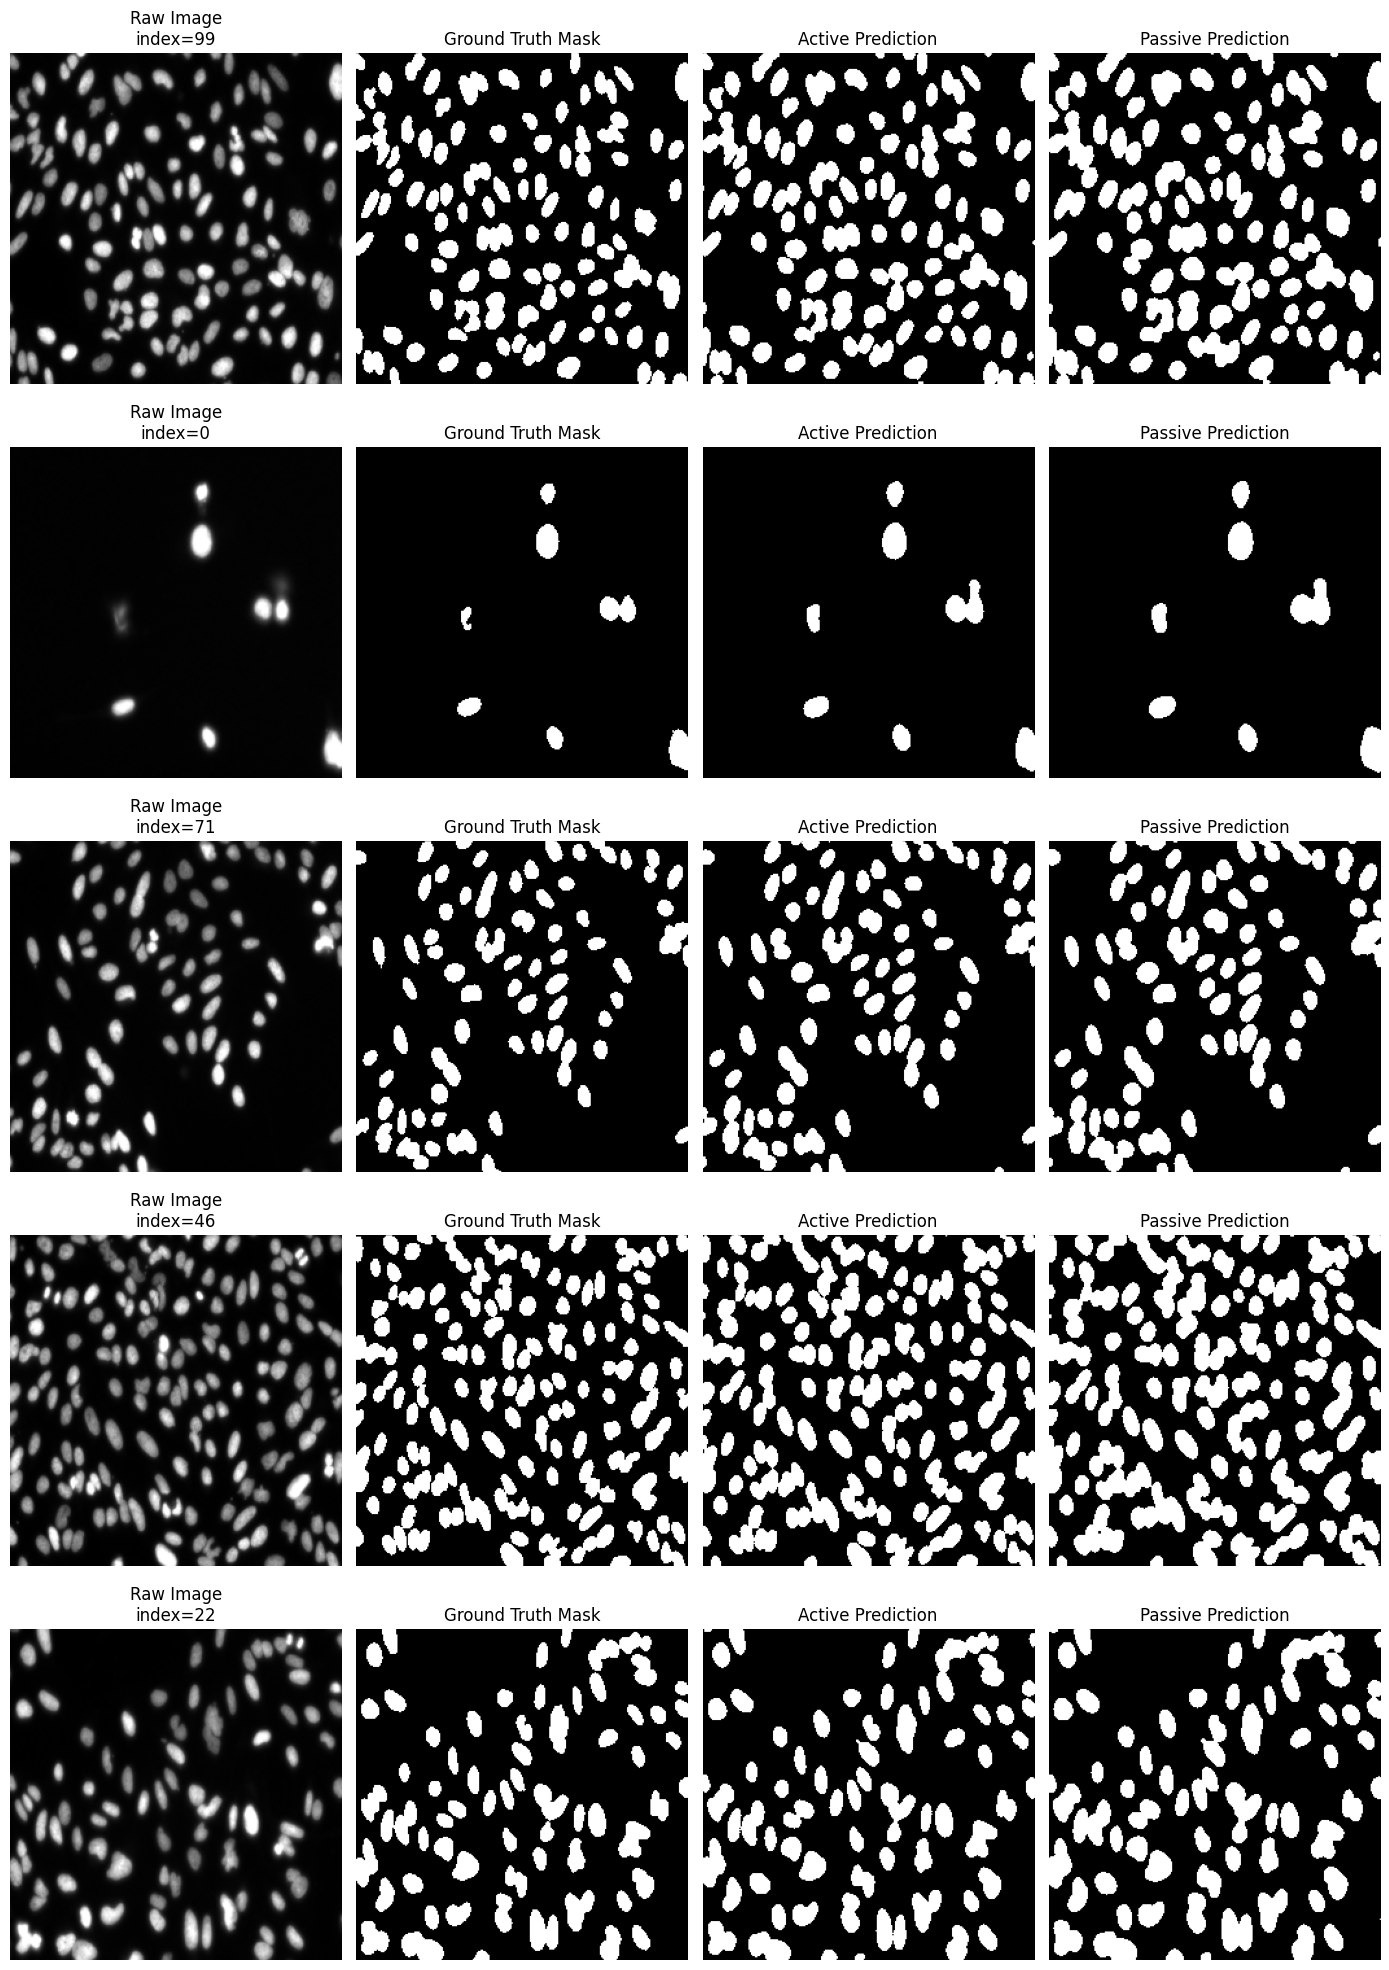

In [54]:
compare_active_vs_passive_predictions(
    active_model,
    passive_model,
    test_dataset,
    DEVICE,
    num_examples=5,
    threshold=0.5
)

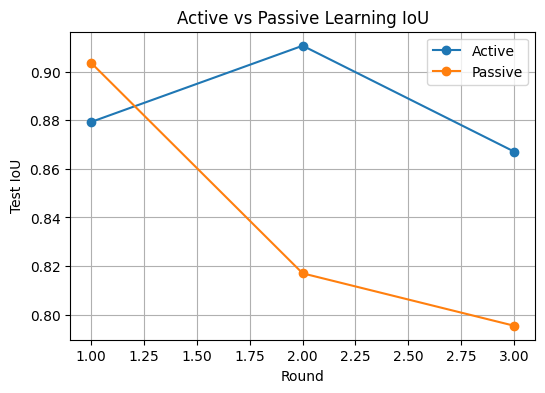

In [57]:
# %% =========================================================
# cell. plot active vs passive IoU
# purpose:
# compare active and passive learning test IoU across rounds
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(active_history_df["round"], active_history_df["test_iou"], marker="o", label="Active")
plt.plot(passive_history_df["round"], passive_history_df["test_iou"], marker="o", label="Passive")
plt.xlabel("Round")
plt.ylabel("Test IoU")
plt.title("Active vs Passive Learning IoU")
plt.legend()
plt.grid(True)
plt.show()

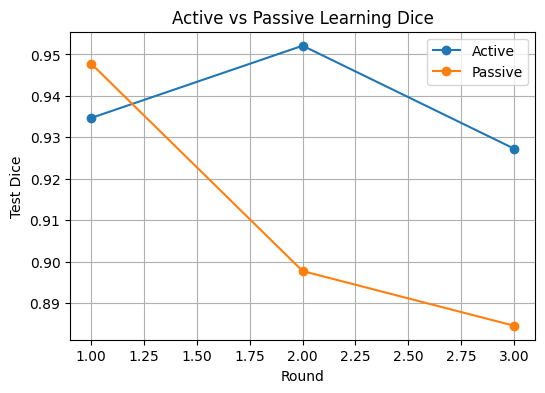

In [58]:
# %% =========================================================
# cell. plot active vs passive Dice
# purpose:
# compare active and passive learning test Dice across rounds
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(active_history_df["round"], active_history_df["test_dice"], marker="o", label="Active")
plt.plot(passive_history_df["round"], passive_history_df["test_dice"], marker="o", label="Passive")
plt.xlabel("Round")
plt.ylabel("Test Dice")
plt.title("Active vs Passive Learning Dice")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
comparison_df = pd.DataFrame({
    "round": active_history_df["round"],
    "active_test_dice": active_history_df["test_dice"],
    "passive_test_dice": passive_history_df["test_dice"],
    "active_test_iou": active_history_df["test_iou"],
    "passive_test_iou": passive_history_df["test_iou"]
})

print(comparison_df)

   round  active_test_dice  passive_test_dice  active_test_iou  \
0      1          0.934686           0.947757         0.879289   
1      2          0.952117           0.897714         0.910607   
2      3          0.927272           0.884519         0.867110   

   passive_test_iou  
0          0.903509  
1          0.817047  
2          0.795514  
